In [1]:
# CELL 1: Mount Google Drive and Setup

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set path to your organized songs folder
DATA_PATH = Path("/content/drive/MyDrive/mbti-tune/data/organized_songs_by_genre")

print(f"Data path exists: {DATA_PATH.exists()}")
print(f"Files in folder: {len(list(DATA_PATH.glob('*.csv')))}")

Mounted at /content/drive
Data path exists: True
Files in folder: 82


In [2]:
# CELL 2: Define target genres and load data

# Define the genres we want to classify
TARGET_GENRES = [
    # Regional Asian pop (what we want to classify)
    'cantopop', 'k-pop', 'j-pop', 'c-pop', 't-pop', 'mandopop', 'indie-pop', 'power-pop', 'pop-film',
    # Western/global genres (reference)
    'pop', 'rock', 'alternative', 'indie', 'electronic', 'edm', 'dance', 'house', 'techno',
    'hip-hop', 'rap', 'r&b', 'soul', 'jazz', 'blues', 'country', 'folk', 'metal', 'punk'
]

# Also include general genres
OTHER_GENRES = ['acoustic', 'ambient', 'chill', 'classical', 'instrumental']

ALL_TARGET_GENRES = TARGET_GENRES + OTHER_GENRES

print(f"Target genres to classify: {len(ALL_TARGET_GENRES)}")
print(f"\nRegional pop genres:")
for g in TARGET_GENRES[:10]:
    print(f"  - {g}")

Target genres to classify: 33

Regional pop genres:
  - cantopop
  - k-pop
  - j-pop
  - c-pop
  - t-pop
  - mandopop
  - indie-pop
  - power-pop
  - pop-film
  - pop


In [3]:
# CELL 3: Load all genre files into one DataFrame

print("Loading genre files...")

all_data = []
genre_counts = {}

for genre in ALL_TARGET_GENRES:
    file_path = DATA_PATH / f"{genre}.csv"
    if file_path.exists():
        df = pd.read_csv(file_path)
        df['genre_label'] = genre
        all_data.append(df)
        genre_counts[genre] = len(df)
        print(f"  Loaded {genre}: {len(df):,} songs")
    else:
        print(f"  ❌ {genre}.csv not found")

if not all_data:
    print("\n❌ No genre files found! Checking available files...")
    available = [f.stem for f in DATA_PATH.glob("*.csv")]
    print(f"Available files: {available[:20]}...")
else:
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"\n✅ Total songs loaded: {len(df_all):,}")
    print(f"✅ Total genres: {df_all['genre_label'].nunique()}")

Loading genre files...
  Loaded cantopop: 589 songs
  Loaded k-pop: 589 songs
  ❌ j-pop.csv not found
  ❌ c-pop.csv not found
  ❌ t-pop.csv not found
  ❌ mandopop.csv not found
  Loaded indie-pop: 589 songs
  Loaded power-pop: 589 songs
  Loaded pop-film: 589 songs
  Loaded pop: 589 songs
  Loaded rock: 589 songs
  ❌ alternative.csv not found
  ❌ indie.csv not found
  Loaded electronic: 589 songs
  Loaded edm: 589 songs
  Loaded dance: 589 songs
  Loaded house: 589 songs
  Loaded techno: 589 songs
  Loaded hip-hop: 589 songs
  ❌ rap.csv not found
  ❌ r&b.csv not found
  Loaded soul: 589 songs
  Loaded jazz: 589 songs
  Loaded blues: 589 songs
  Loaded country: 589 songs
  Loaded folk: 589 songs
  Loaded metal: 589 songs
  Loaded punk: 589 songs
  Loaded acoustic: 589 songs
  Loaded ambient: 589 songs
  Loaded chill: 589 songs
  Loaded classical: 589 songs
  ❌ instrumental.csv not found

✅ Total songs loaded: 14,136
✅ Total genres: 24


In [4]:
# CELL 4: Feature selection and preprocessing

# Audio features to use for classification
AUDIO_FEATURES = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'speechiness', 'loudness', 'tempo', 'liveness'
]

# Check which features are available
available_features = [f for f in AUDIO_FEATURES if f in df_all.columns]
missing_features = [f for f in AUDIO_FEATURES if f not in df_all.columns]

print(f"Available features: {len(available_features)}/{len(AUDIO_FEATURES)}")
if missing_features:
    print(f"Missing features: {missing_features}")

# Prepare features
X = df_all[available_features].values
y = df_all['genre_label'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Handle missing values
X = np.nan_to_num(X, nan=0.0)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")

Available features: 9/9

Feature matrix shape: (14136, 9)
Labels shape: (14136,)
Scaled feature matrix shape: (14136, 9)


In [5]:
# CELL 5: Train/Test split

from sklearn.model_selection import train_test_split

# Split data (stratified to maintain genre distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print(f"\nTraining set genre distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for genre, count in zip(unique, counts):
    print(f"  {genre}: {count} songs")

Train size: 11,308
Test size: 2,828

Training set genre distribution:
  acoustic: 472 songs
  ambient: 471 songs
  blues: 471 songs
  cantopop: 471 songs
  chill: 471 songs
  classical: 471 songs
  country: 471 songs
  dance: 471 songs
  edm: 472 songs
  electronic: 471 songs
  folk: 471 songs
  hip-hop: 471 songs
  house: 471 songs
  indie-pop: 471 songs
  jazz: 471 songs
  k-pop: 471 songs
  metal: 472 songs
  pop: 471 songs
  pop-film: 472 songs
  power-pop: 471 songs
  punk: 471 songs
  rock: 471 songs
  soul: 471 songs
  techno: 471 songs


In [6]:
# CELL 6: Train a Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Random baseline: {1/len(np.unique(y))*100:.1f}%")

Training Random Forest Classifier...

✅ Test Accuracy: 0.2691 (26.91%)
Random baseline: 4.2%


In [7]:
# CELL 7: Classification Report by Genre

print("\n" + "="*60)
print("CLASSIFICATION REPORT BY GENRE")
print("="*60)

print(classification_report(y_test, y_pred))

# Per-genre accuracy
print("\n" + "="*60)
print("PER-GENRE ACCURACY")
print("="*60)

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

results_df = pd.DataFrame({
    'Genre': np.unique(y_test),
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Samples': support
}).sort_values('F1-Score', ascending=False)

print(results_df.to_string(index=False))


CLASSIFICATION REPORT BY GENRE
              precision    recall  f1-score   support

    acoustic       0.16      0.17      0.17       117
     ambient       0.47      0.47      0.47       118
       blues       0.17      0.13      0.14       118
    cantopop       0.25      0.40      0.31       118
       chill       0.16      0.15      0.16       118
   classical       0.59      0.55      0.57       118
     country       0.14      0.19      0.16       118
       dance       0.18      0.14      0.16       118
         edm       0.32      0.21      0.26       117
  electronic       0.19      0.15      0.17       118
        folk       0.15      0.12      0.13       118
     hip-hop       0.35      0.64      0.45       118
       house       0.32      0.31      0.31       118
   indie-pop       0.10      0.06      0.07       118
        jazz       0.29      0.25      0.27       118
       k-pop       0.20      0.24      0.22       118
       metal       0.43      0.62      0.51      

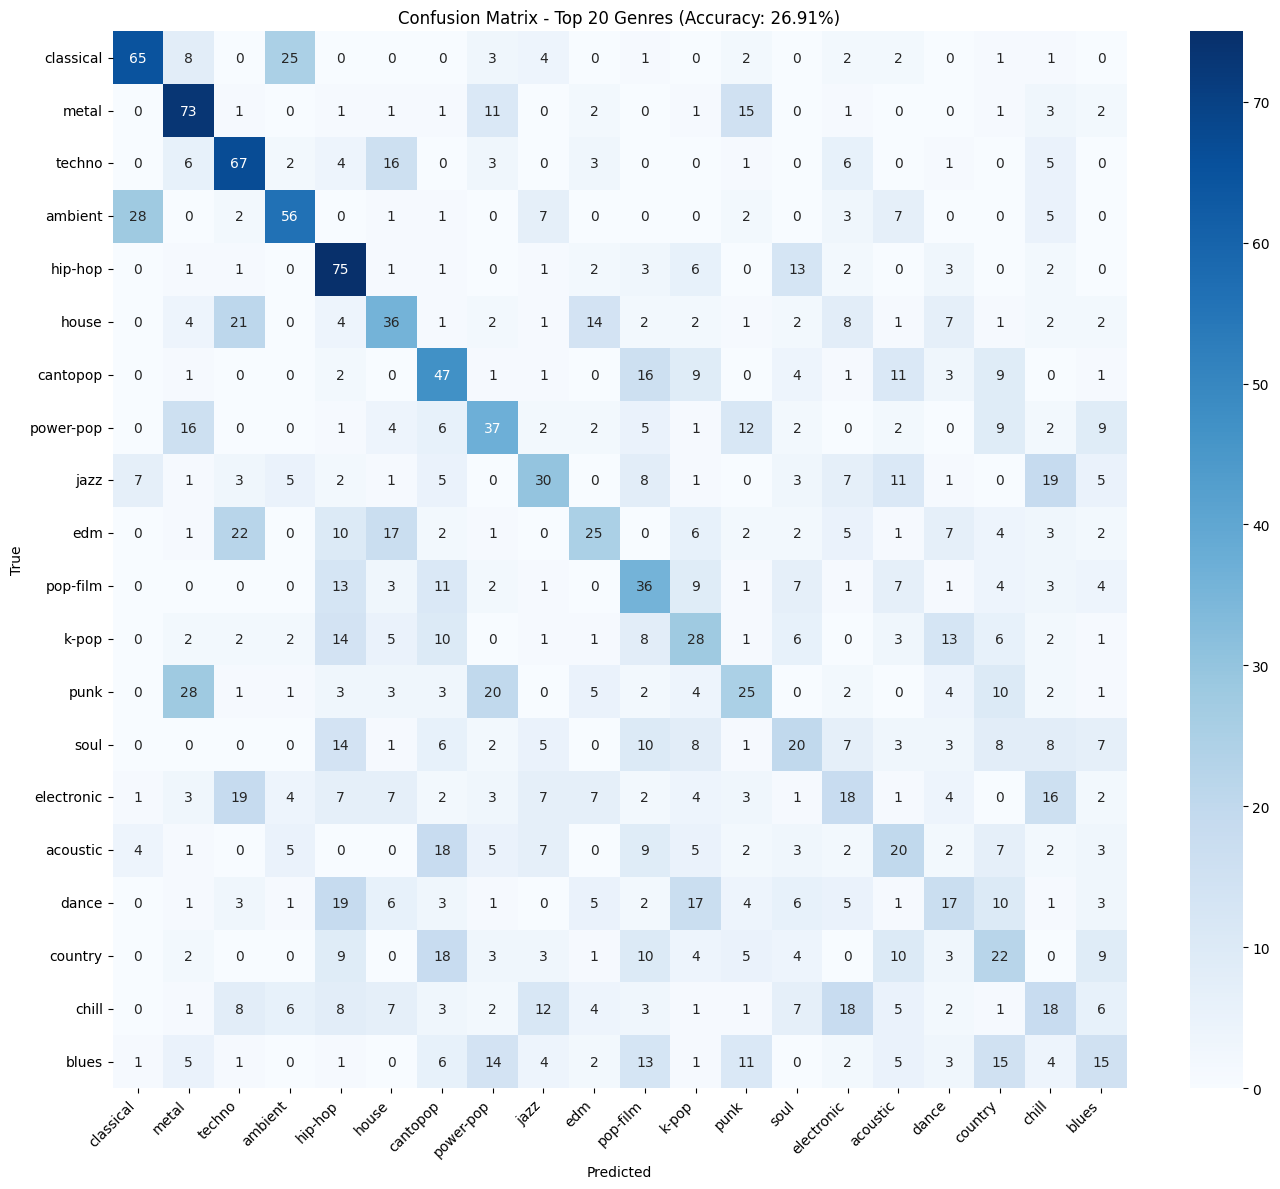

In [8]:
# CELL 8: Confusion Matrix Visualization

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Get unique genres
unique_genres = np.unique(y_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_genres)

# Plot (show only top genres for readability)
top_n = min(20, len(unique_genres))
top_genres = results_df.head(top_n)['Genre'].values
top_indices = [np.where(unique_genres == g)[0][0] for g in top_genres]

plt.figure(figsize=(14, 12))
sns.heatmap(cm[np.ix_(top_indices, top_indices)],
            annot=True, fmt='d', cmap='Blues',
            xticklabels=top_genres, yticklabels=top_genres)
plt.title(f'Confusion Matrix - Top {top_n} Genres (Accuracy: {accuracy:.2%})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE
            feature  importance
3      acousticness    0.124793
6          loudness    0.118590
0      danceability    0.118181
1            energy    0.114988
4  instrumentalness    0.112192
5       speechiness    0.110592
2           valence    0.110000
7             tempo    0.101929
8          liveness    0.088735


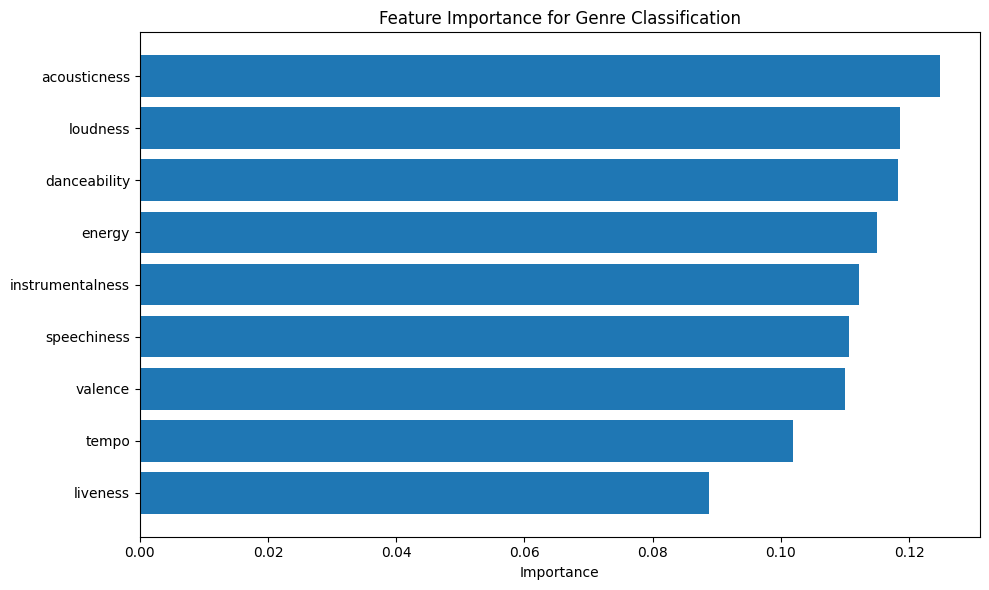

In [9]:
# CELL 9: Feature Importance Analysis

feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Genre Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# CELL 10: Save the model for later use

import joblib

# Save model and scaler
MODEL_PATH = Path("/content/drive/MyDrive/mbti-tune/data/processed/genre_classifier.pkl")
SCALER_PATH = Path("/content/drive/MyDrive/mbti-tune/data/processed/genre_scaler.pkl")

joblib.dump(rf_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f"✅ Model saved to {MODEL_PATH}")
print(f"✅ Scaler saved to {SCALER_PATH}")

✅ Model saved to /content/drive/MyDrive/mbti-tune/data/processed/genre_classifier.pkl
✅ Scaler saved to /content/drive/MyDrive/mbti-tune/data/processed/genre_scaler.pkl


In [11]:
# CELL 11: Test on specific examples

print("\n" + "="*60)
print("TEST ON SPECIFIC EXAMPLES")
print("="*60)

# Pick random test samples
test_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in test_indices:
    true_genre = y_test[idx]
    pred_genre = y_pred[idx]
    confidence = np.max(rf_model.predict_proba(X_test[idx:idx+1]))

    # Get feature values for this song
    features_dict = {available_features[i]: X_test[idx][i] for i in range(len(available_features))}

    print(f"\n🎵 Song {idx}:")
    print(f"   True genre: {true_genre}")
    print(f"   Predicted: {pred_genre}")
    print(f"   Confidence: {confidence:.2%}")
    print(f"   Danceability: {features_dict.get('danceability', 'N/A'):.3f}")
    print(f"   Energy: {features_dict.get('energy', 'N/A'):.3f}")
    print(f"   Tempo: {features_dict.get('tempo', 'N/A'):.1f} BPM")


TEST ON SPECIFIC EXAMPLES

🎵 Song 947:
   True genre: power-pop
   Predicted: indie-pop
   Confidence: 24.85%
   Danceability: -0.390
   Energy: 0.272
   Tempo: 0.5 BPM

🎵 Song 2008:
   True genre: cantopop
   Predicted: cantopop
   Confidence: 22.89%
   Danceability: -0.026
   Energy: -0.058
   Tempo: 0.3 BPM

🎵 Song 252:
   True genre: metal
   Predicted: metal
   Confidence: 61.39%
   Danceability: -1.627
   Energy: 1.250
   Tempo: 0.9 BPM

🎵 Song 1760:
   True genre: metal
   Predicted: metal
   Confidence: 16.63%
   Danceability: -1.187
   Energy: 0.521
   Tempo: 0.1 BPM

🎵 Song 959:
   True genre: jazz
   Predicted: jazz
   Confidence: 60.64%
   Danceability: 0.730
   Energy: -0.093
   Tempo: -1.1 BPM


In [12]:
# CELL 12: Function to predict genre for a new song

def predict_genre(audio_features, model, scaler, feature_names):
    """
    Predict genre from audio features

    Args:
        audio_features: dict with feature names as keys
        model: trained RandomForest model
        scaler: fitted StandardScaler
        feature_names: list of feature names in correct order

    Returns:
        predicted genre and confidence
    """
    # Create feature vector
    feature_vector = []
    for f in feature_names:
        feature_vector.append(audio_features.get(f, 0))

    # Scale and predict
    X = scaler.transform([feature_vector])
    pred = model.predict(X)[0]
    proba = np.max(model.predict_proba(X))

    return pred, proba

# Example usage
sample_features = {
    'danceability': 0.75,
    'energy': 0.85,
    'valence': 0.7,
    'acousticness': 0.1,
    'instrumentalness': 0.0,
    'speechiness': 0.05,
    'loudness': -5.0,
    'tempo': 128.0,
    'liveness': 0.15
}

pred_genre, confidence = predict_genre(sample_features, rf_model, scaler, available_features)
print(f"\n📝 Example prediction:")
print(f"   Features: {sample_features}")
print(f"   Predicted genre: {pred_genre} (confidence: {confidence:.2%})")


📝 Example prediction:
   Features: {'danceability': 0.75, 'energy': 0.85, 'valence': 0.7, 'acousticness': 0.1, 'instrumentalness': 0.0, 'speechiness': 0.05, 'loudness': -5.0, 'tempo': 128.0, 'liveness': 0.15}
   Predicted genre: k-pop (confidence: 19.99%)


In [13]:
# CELL 13: Analyze confusion between genres

print("\n" + "="*60)
print("TOP CONFUSIONS BETWEEN GENRES")
print("="*60)

# Get confusion pairs
cm_full = confusion_matrix(y_test, y_pred, labels=unique_genres)
confusion_pairs = []

for i, true_g in enumerate(unique_genres):
    for j, pred_g in enumerate(unique_genres):
        if i != j and cm_full[i, j] > 0:
            confusion_pairs.append((true_g, pred_g, cm_full[i, j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nMost frequently confused genre pairs:")
for true_g, pred_g, count in confusion_pairs[:15]:
    print(f"   {true_g} → {pred_g}: {count} songs")

# Check how well regional pop genres are classified
print("\n" + "="*60)
print("REGIONAL POP GENRE PERFORMANCE")
print("="*60)

regional_genres = ['cantopop', 'k-pop', 'j-pop', 'pop', 'indie-pop', 'power-pop']
for genre in regional_genres:
    if genre in results_df['Genre'].values:
        row = results_df[results_df['Genre'] == genre].iloc[0]
        print(f"\n{genre.upper()}:")
        print(f"   Precision: {row['Precision']:.2%}")
        print(f"   Recall: {row['Recall']:.2%}")
        print(f"   F1-Score: {row['F1-Score']:.2%}")
        print(f"   Samples: {int(row['Samples'])}")


TOP CONFUSIONS BETWEEN GENRES

Most frequently confused genre pairs:
   ambient → classical: 28 songs
   punk → metal: 28 songs
   classical → ambient: 25 songs
   edm → techno: 22 songs
   house → techno: 21 songs
   punk → power-pop: 20 songs
   dance → hip-hop: 19 songs
   electronic → techno: 19 songs
   jazz → chill: 19 songs
   acoustic → cantopop: 18 songs
   chill → electronic: 18 songs
   country → cantopop: 18 songs
   dance → k-pop: 17 songs
   edm → house: 17 songs
   pop → k-pop: 17 songs

REGIONAL POP GENRE PERFORMANCE

CANTOPOP:
   Precision: 25.41%
   Recall: 39.83%
   F1-Score: 31.02%
   Samples: 118

K-POP:
   Precision: 20.44%
   Recall: 23.73%
   F1-Score: 21.96%
   Samples: 118

POP:
   Precision: 14.58%
   Recall: 5.93%
   F1-Score: 8.43%
   Samples: 118

INDIE-POP:
   Precision: 9.72%
   Recall: 5.93%
   F1-Score: 7.37%
   Samples: 118

POWER-POP:
   Precision: 28.46%
   Recall: 31.36%
   F1-Score: 29.84%
   Samples: 118



FINAL SUMMARY

📊 Genre Classification Results:
   - Total genres classified: 24
   - Test accuracy: 26.91%
   - Random baseline: 4.2%
   
🎯 Best performing genres:
       Genre  F1-Score
classical  0.567686
    metal  0.510490
   techno  0.492647
   
⚠️ Worst performing genres:
       Genre  F1-Score
      pop  0.084337
indie-pop  0.073684
     rock  0.036364

🔧 Feature importance:
   Top feature: acousticness (0.125)
   Second: loudness (0.119)



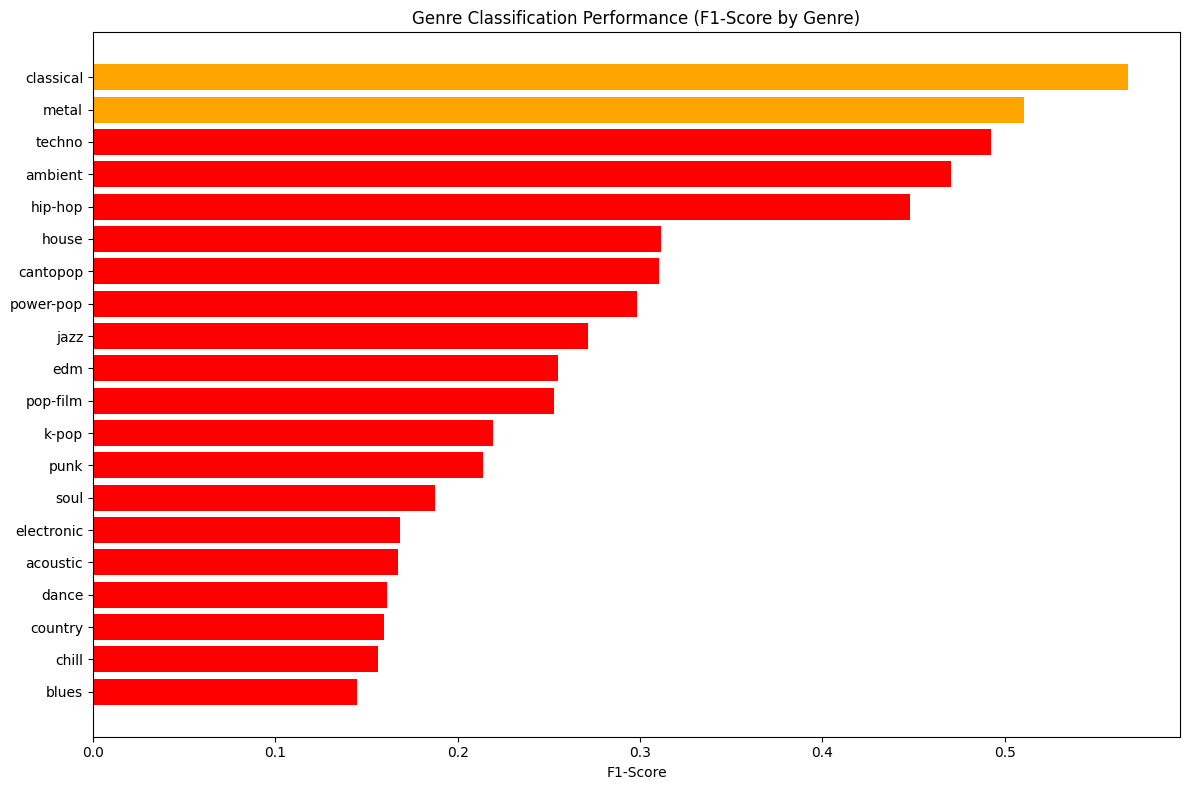

In [14]:
# CELL 14: Summary and visualization

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
📊 Genre Classification Results:
   - Total genres classified: {len(unique_genres)}
   - Test accuracy: {accuracy:.2%}
   - Random baseline: {1/len(unique_genres):.1%}

🎯 Best performing genres:
   {results_df.head(3)[['Genre', 'F1-Score']].to_string(index=False)}

⚠️ Worst performing genres:
   {results_df.tail(3)[['Genre', 'F1-Score']].to_string(index=False)}

🔧 Feature importance:
   Top feature: {feature_importance.iloc[0]['feature']} ({feature_importance.iloc[0]['importance']:.3f})
   Second: {feature_importance.iloc[1]['feature']} ({feature_importance.iloc[1]['importance']:.3f})
""")

# Plot genre performance
plt.figure(figsize=(12, 8))
top_performers = results_df.head(20)
colors = ['green' if f1 > 0.7 else 'orange' if f1 > 0.5 else 'red' for f1 in top_performers['F1-Score']]
plt.barh(top_performers['Genre'], top_performers['F1-Score'], color=colors)
plt.xlabel('F1-Score')
plt.title('Genre Classification Performance (F1-Score by Genre)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()